=== Dataset Shape ===
(614, 13)

=== Columns ===
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

=== First 5 Rows ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

=== Summary Statistics ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



=== Target Value Counts ===
Loan_Status
Y    422
N    192
Name: count, dtype: int64

=== Missing Values Before Cleaning ===


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14



=== Missing Values After Cleaning ===


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


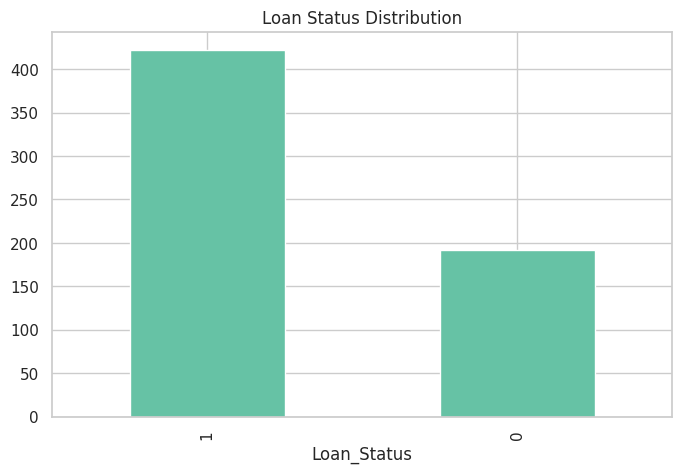

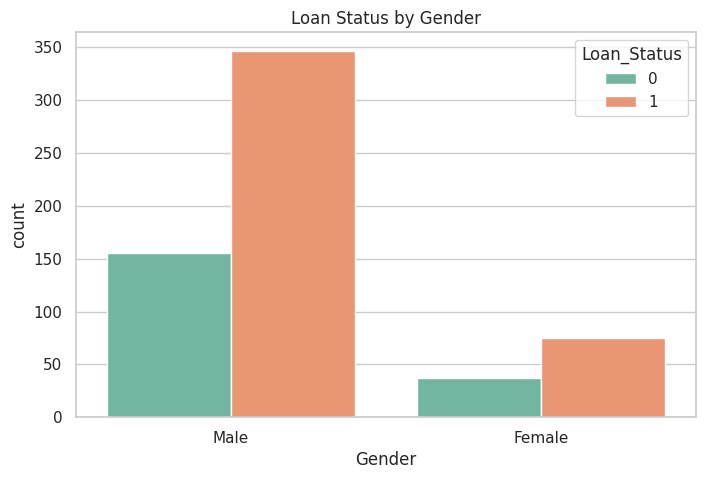

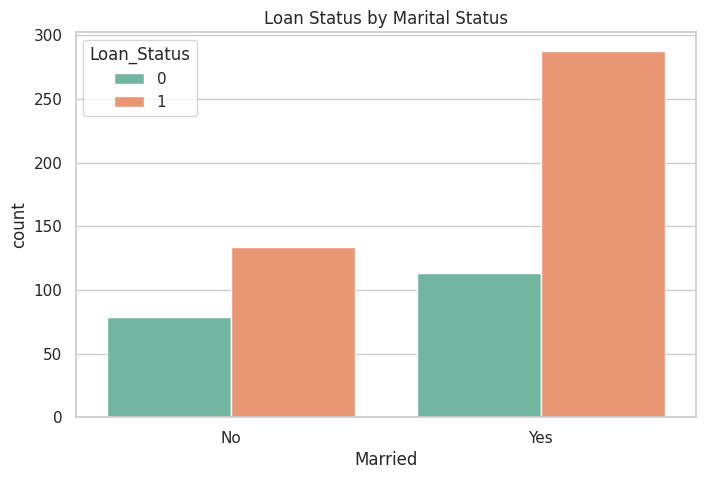

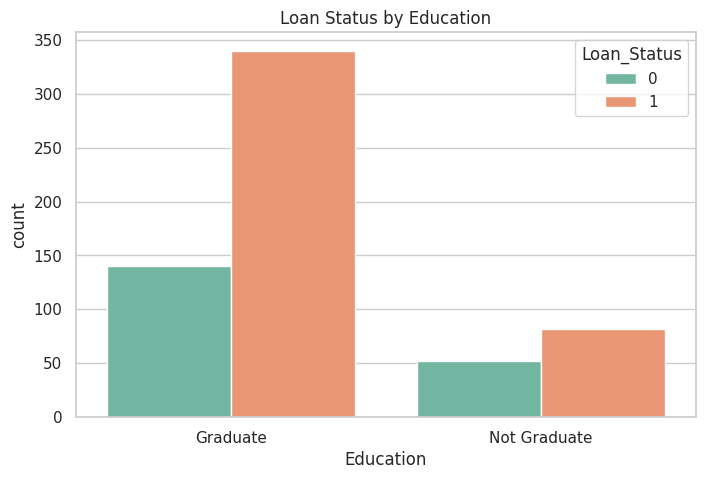

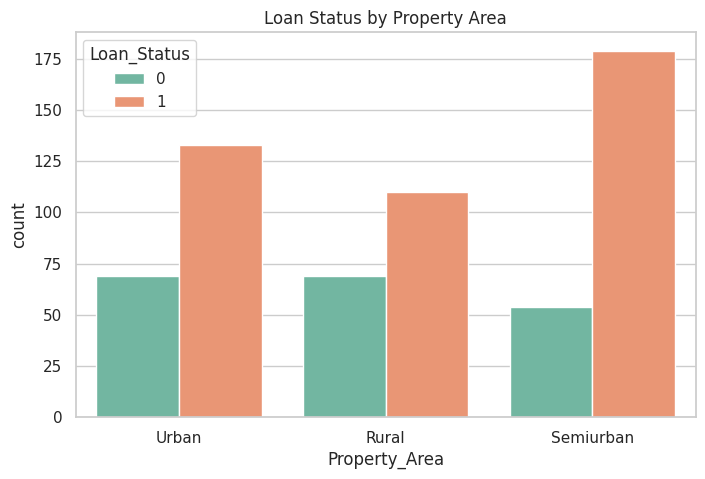

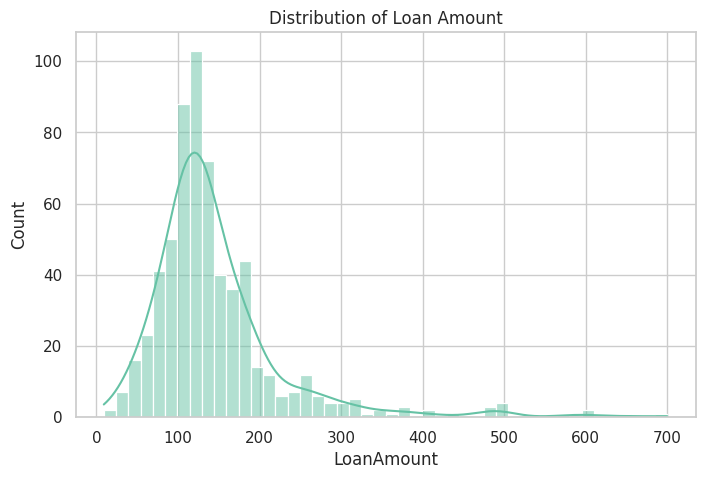

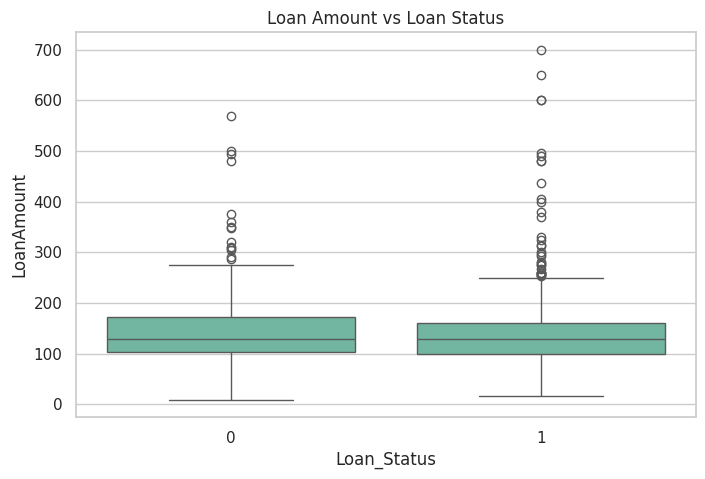

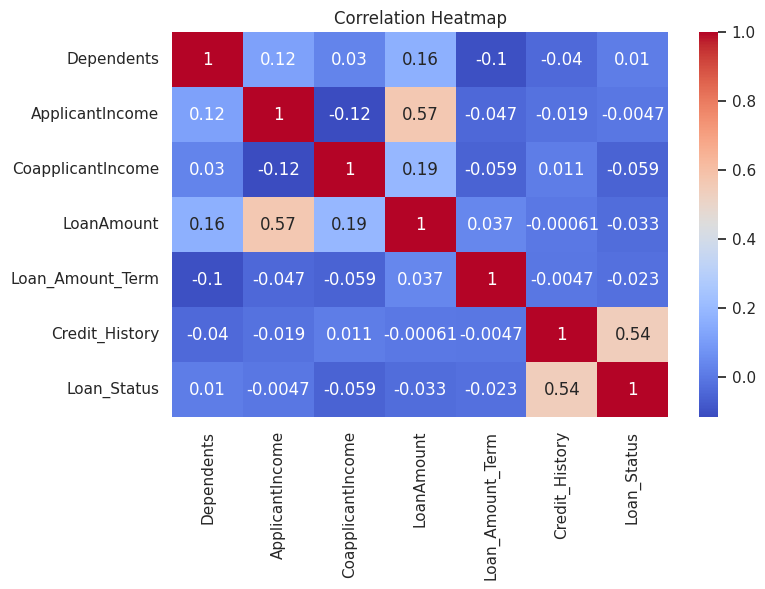


=== Logistic Regression ===
Accuracy : 0.8617886178861789
Precision: 0.84
Recall   : 0.9882352941176471
F1-score : 0.9081081081081082
ROC-AUC  : 0.7835913312693499

Confusion Matrix:
 [[22 16]
 [ 1 84]]

=== Support Vector Machine ===
Accuracy : 0.8536585365853658
Precision: 0.8316831683168316
Recall   : 0.9882352941176471
F1-score : 0.9032258064516129
ROC-AUC  : 0.7704334365325077

Confusion Matrix:
 [[21 17]
 [ 1 84]]

=== Random Forest ===
Accuracy : 0.8292682926829268
Precision: 0.8404255319148937
Recall   : 0.9294117647058824
F1-score : 0.88268156424581
ROC-AUC  : 0.7673374613003097

Confusion Matrix:
 [[23 15]
 [ 6 79]]

=== Decision Tree ===
Accuracy : 0.7479674796747967
Precision: 0.8068181818181818
Recall   : 0.8352941176470589
F1-score : 0.8208092485549133
ROC-AUC  : 0.6939628482972137

Confusion Matrix:
 [[21 17]
 [14 71]]

=== MODEL ACCURACY COMPARISON ===


,Accuracy
Logistic Regression,0.861789
SVM,0.853659
Random Forest,0.829268
Decision Tree,0.747967



*** BEST MODEL: Logistic Regression ** *


In [ ]:
# ============================================================
# IS316 PROJECT – LOAN PREDICTION CLASSIFICATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Modeling + Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

# Suppressing FutureWarnings to keep the output clean. These warnings are related to inplace = true
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# DATA COLLECTION & INITIAL EXPLORATION
df = pd.read_csv("train.csv")

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Columns ===")
print(df.columns)

print("\n=== First 5 Rows ===")
display(df.head())

print("\n=== Info ===")
df.info()

print("\n=== Summary Statistics ===")
display(df.describe())

print("\n=== Target Value Counts ===")
print(df["Loan_Status"].value_counts())


#DATA CLEANING & PREPROCESSING
print("\n=== Missing Values Before Cleaning ===")
display(df.isnull().sum())

# Fill missing categorical features with mode
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Married"].fillna(df["Married"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

# Replace '3+' with 3
df["Dependents"].replace("3+", 3, inplace=True)
df["Dependents"] = pd.to_numeric(df["Dependents"])

# Fill numeric missing values
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)

print("\n=== Missing Values After Cleaning ===")
display(df.isnull().sum())

# Encode target variable
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

# One-hot encoding of categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=["Gender", "Married", "Self_Employed", "Education", "Property_Area"],
    drop_first=True)

# Remove ID column
df_encoded = df_encoded.drop(columns=["Loan_ID"])
# Split into features and target
X = df_encoded.drop("Loan_Status", axis=1)
y = df_encoded["Loan_Status"]


# EXPLORATORY DATA ANALYSIS (EDA)
# 3.1 Class balance
df["Loan_Status"].value_counts().plot(kind="bar", title="Loan Status Distribution")
plt.show()

# 3.2 Gender
sns.countplot(data=df, x="Gender", hue="Loan_Status")
plt.title("Loan Status by Gender")
plt.show()

# 3.3 Married
sns.countplot(data=df, x="Married", hue="Loan_Status")
plt.title("Loan Status by Marital Status")
plt.show()

# 3.4 Education
sns.countplot(data=df, x="Education", hue="Loan_Status")
plt.title("Loan Status by Education")
plt.show()

# 3.5 Property_Area
sns.countplot(data=df, x="Property_Area", hue="Loan_Status")
plt.title("Loan Status by Property Area")
plt.show()

# 3.6 LoanAmount distribution
sns.histplot(df["LoanAmount"], kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

# 3.7 LoanAmount vs target
sns.boxplot(data=df, x="Loan_Status", y="LoanAmount")
plt.title("Loan Amount vs Loan Status")
plt.show()

# 3.8 Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Model Building
X = df_encoded.drop("Loan_Status", axis=1)
y = df_encoded["Loan_Status"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2, random_state=42,stratify=y)

# Scale numeric features
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
                "Loan_Amount_Term", "Credit_History", "Dependents"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Build models
log_model = LogisticRegression(max_iter=5000, random_state=42).fit(X_train_scaled, y_train)
svm_model = SVC(kernel="linear", random_state=42).fit(X_train_scaled, y_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)
dt_model = DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train)


# Model Evaluation
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

# Predictions
log_pred = log_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)
rf_pred  = rf_model.predict(X_test_scaled)
dt_pred  = dt_model.predict(X_test_scaled)

evaluate("Logistic Regression", y_test, log_pred)
evaluate("Support Vector Machine", y_test, svm_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("Decision Tree", y_test, dt_pred)

results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred) }

print("\n=== MODEL ACCURACY COMPARISON ===")
display(pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"]))

best_model = max(results, key=results.get)
print(f"\n*** BEST MODEL: {best_model} ** *")
